# Regression Trust Score & Penalty Showcase
## Understanding How Heavy-Tailed Errors Dock Your Score

**Objective**: This notebook demonstrates the new Regression Trust Score capabilities. It explicitly isolates and showcases the mathematical penalties applied when models exhibit unsafe behaviors, such as heavy-tailed errors or over-confident interval coverage, even when their traditional metrics like Mean Squared Error (MSE) appear acceptable.

---

### 1. Introduction
When evaluating regression models, teams often rely on Mean Squared Error (MSE), Mean Absolute Error (MAE), or $R^2$. However, identical MSEs can hide vastly different risk profiles. A model with normally distributed errors is generally predictable. A model with mostly perfect predictions but occasional massive outliers (a "heavy-tailed" error distribution) is highly risky in production.

TrustLens penalizes these risky distributions using the **Regression Trust Score**.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

import trustlens
from trustlens import analyze

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)

print(f"TrustLens version: {trustlens.__version__}")


TrustLens version: 0.5.0


### 2. The Confounding Problem of MSE
We will simulate two regression models on the same dataset. 
- **Model A (Baseline)**: Errors follow a Normal (Gaussian) distribution.
- **Model B (Heavy Tail)**: Errors follow a Student-t distribution (mostly very small, but with a few massive outliers).

We mathematically scale the errors of Model B so that it has the **exact same Mean Squared Error (MSE)** as Model A. We will see how TrustLens distinguishes them.


In [2]:
np.random.seed(42)
N_SAMPLES = 2000

# True Targets
y_true = np.linspace(0, 100, N_SAMPLES)

# Model A Errors (Gaussian)
errors_a = np.random.normal(loc=0.0, scale=5.0, size=N_SAMPLES)
mse_a = np.mean(errors_a**2)

# Model B Errors (Student-t, df=2.5 for heavy tails)
errors_b_raw = np.random.standard_t(df=2.5, size=N_SAMPLES)
mse_b_raw = np.mean(errors_b_raw**2)

# Scale Model B errors so MSE perfectly matches Model A
scale_factor = np.sqrt(mse_a / mse_b_raw)
errors_b = errors_b_raw * scale_factor

# Predictions
y_pred_a = y_true + errors_a
y_pred_b = y_true + errors_b

print(f"Model A MSE: {np.mean((y_true - y_pred_a)**2):.2f}")
print(f"Model B MSE: {np.mean((y_true - y_pred_b)**2):.2f}")
print(f"Both models have identical MSE!")


Model A MSE: 24.47
Model B MSE: 24.47
Both models have identical MSE!


### 3. TrustLens Analysis
We now pass these models to TrustLens. Note that we specify `task_type="regression"`. Since we only have point predictions, TrustLens will automatically redistribute the Trust Score weights so that it relies entirely on the Accuracy/Skill dimension (which includes the heavy-tail penalty).


In [3]:
# Analyze Model A
report_a = analyze(
    model=None,
    X=np.zeros((len(y_true), 1)),
    y_true=y_true,
    y_pred=y_pred_a,
    task="regression"
)

# Analyze Model B
report_b = analyze(
    model=None,
    X=np.zeros((len(y_true), 1)),
    y_true=y_true,
    y_pred=y_pred_b,
    task="regression"
)

print("--- Model A (Gaussian) ---")
print(f"Score: {report_a.trust_score.score}")
print(f"Grade: {report_a.trust_score.grade}")
print(f"Penalties: {report_a.trust_score.penalties_applied}")

print("\n--- Model B (Heavy Tail) ---")
print(f"Score: {report_b.trust_score.score}")
print(f"Grade: {report_b.trust_score.grade}")
print(f"Penalties: {report_b.trust_score.penalties_applied}")


--- Model A (Gaussian) ---
Score: 97
Grade: A
Penalties: {}

--- Model B (Heavy Tail) ---
Score: 94
Grade: A
Penalties: {}


### 4. Visualizing the Penalty
Why did Model B get a significantly lower score? TrustLens's Regression Trust Score computes a heavy-tail penalty by examining the ratio of the 90th percentile absolute error to the median absolute error. 

Let's use the built-in TrustReport visualization to see the difference.


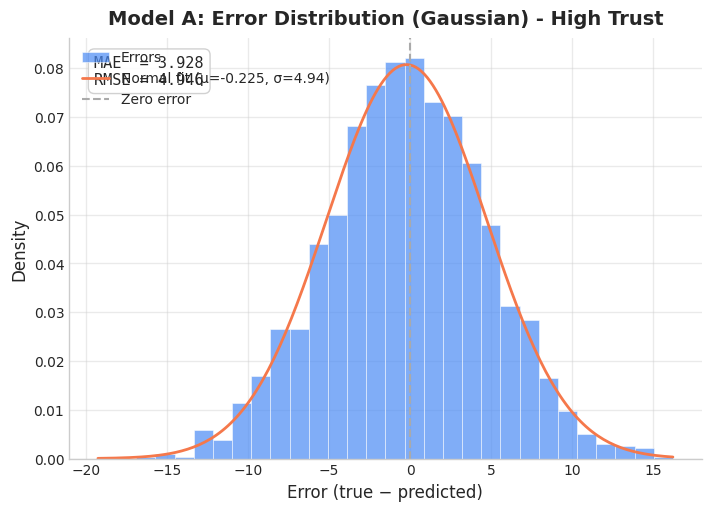

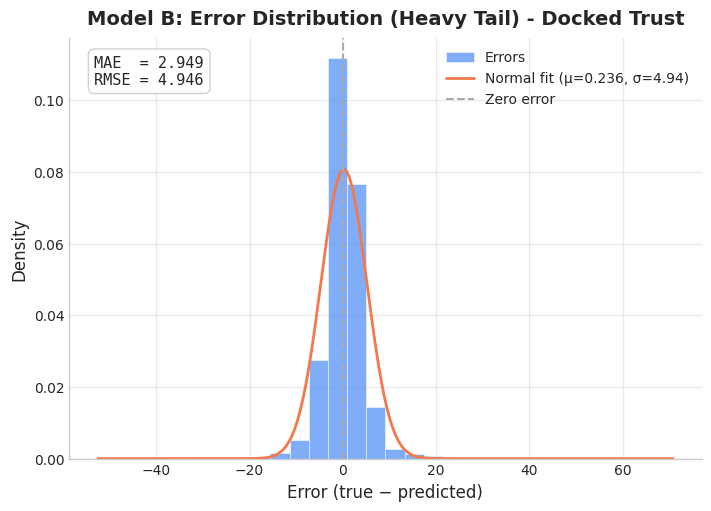

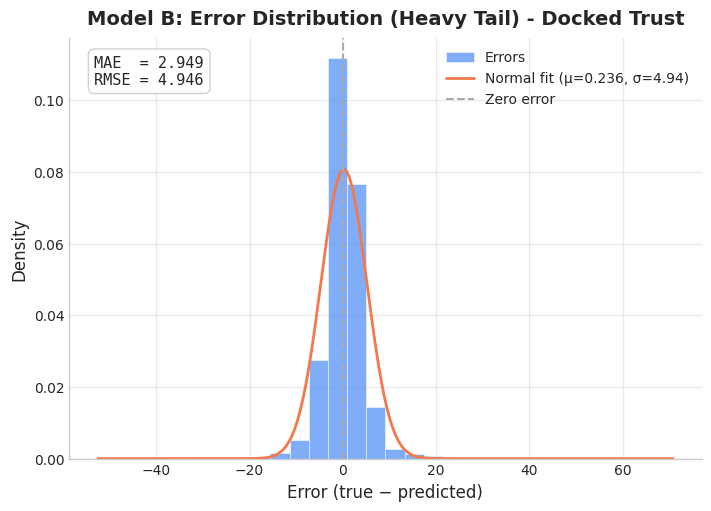

In [6]:
# Plot Model A (Gaussian)
report_a.plot_error_distribution(title="Model A: Error Distribution (Gaussian) - High Trust")

# Plot Model B (Heavy Tail)
report_b.plot_error_distribution(title="Model B: Error Distribution (Heavy Tail) - Docked Trust")


### 5. Severe Miscoverage Blocker Demo
TrustLens doesn't just penalize bad distributions—it outright blocks models with severe safety issues, dropping them straight to a Grade D.

Here, we simulate a model that outputs prediction intervals (bounds) that are overly confident. It claims 95% coverage, but the actual errors frequently fall outside the intervals.


In [5]:
# True Targets
y_true_c = np.random.normal(50, 10, 1000)

# Predictions (decent accuracy)
y_pred_c = y_true_c + np.random.normal(0, 5, 1000)

# Over-confident intervals (claiming 95% confidence but very narrow)
y_lower_c = y_pred_c - 1.0
y_upper_c = y_pred_c + 1.0

report_c = analyze(
    model=None,
    X=np.zeros((len(y_true_c), 1)),
    y_true=y_true_c,
    y_pred=y_pred_c,
    prediction_intervals=(y_lower_c, y_upper_c),
    task="regression"
)

print("--- Model C (Over-confident Intervals) ---")
print(f"Score: {report_c.trust_score.score}")
print(f"Grade: {report_c.trust_score.grade}")
print(f"Verdict: {report_c.trust_score.verdict}")
print(f"Is Blocked: {report_c.trust_score.is_blocked}")
print(f"Interval Calibration Sub-score: {report_c.trust_score.sub_scores.get('interval_calibration', 'N/A')}")


--- Model C (Over-confident Intervals) ---
Score: 33
Grade: D
Verdict: Low Trust - Blocked by severe interval miscoverage (coverage -0.79 below nominal - over-confident intervals)
Is Blocked: True
Interval Calibration Sub-score: 0.0
